-------------------------
number of columns: 14
number of rows: 1025
-------------------------
-------------------------
COLUMN : TYPE
age  :  int64
sex  :  int64
cp  :  int64
trestbps  :  int64
chol  :  int64
fbs  :  int64
restecg  :  int64
thalach  :  int64
exang  :  int64
oldpeak  :  float64
slope  :  int64
ca  :  int64
thal  :  int64
target  :  int64
-------------------------
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   
5   58    0   0       100   248    0        0      122      0      1.0      1   
6   58    1   0       114   318    0        2     

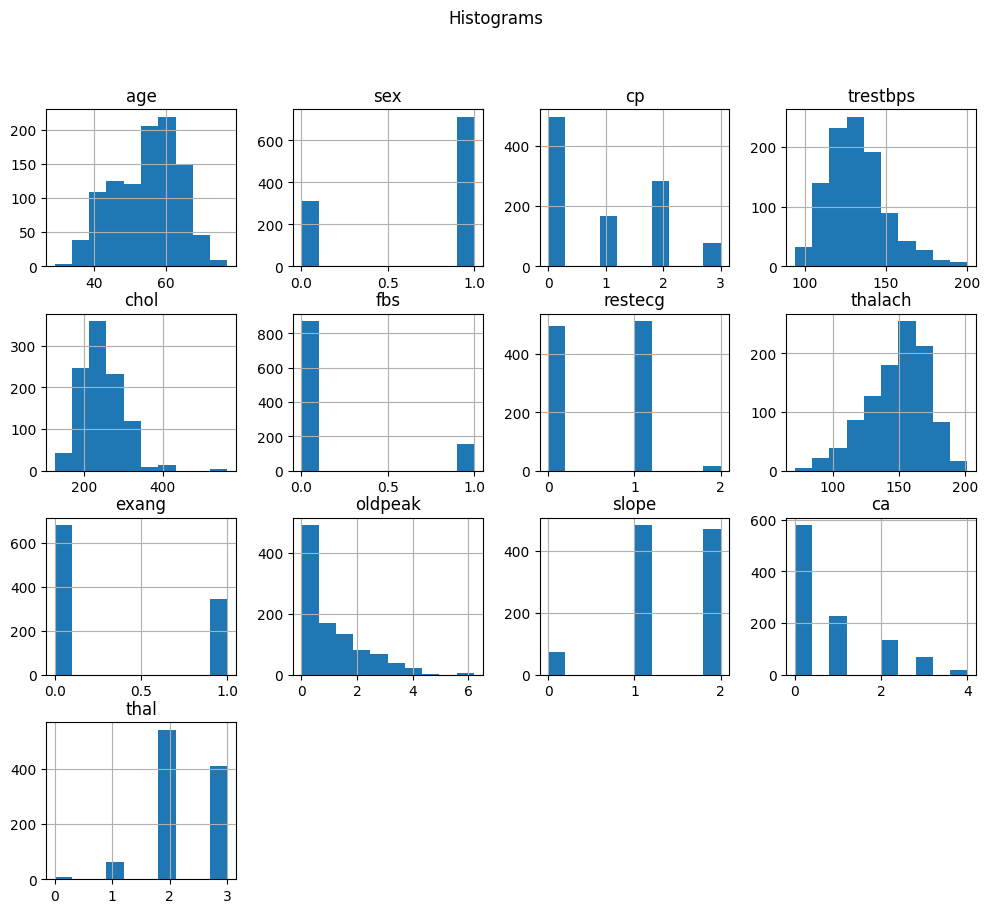

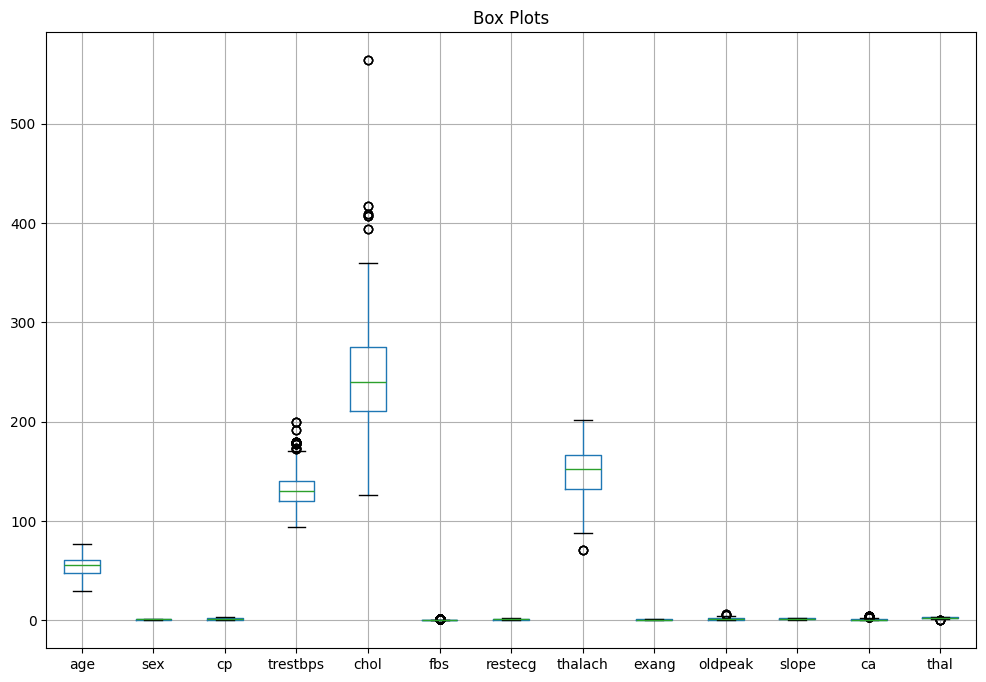

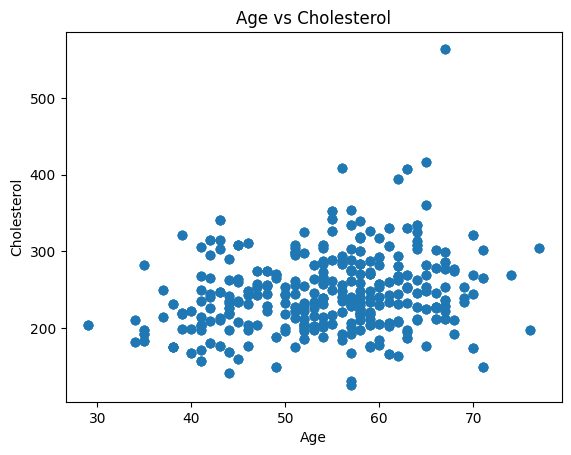

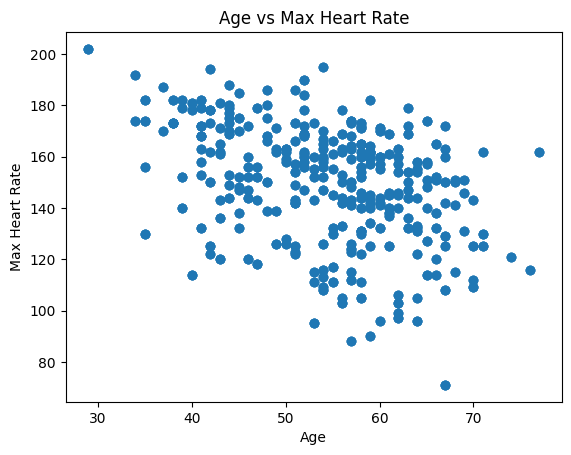

- Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
dtype: int64
- Number of duplicate rows: 723
- Doublons supprimés. Data Current Shape:
-------------------------
number of columns: 13
number of rows: 302
-------------------------
- Variables catégorielles encodées. 
- Current columns: Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='object')
- Features pour clustering: 13
- Features standardisées. Shape:
-------------------------
number of columns: 13
number of rows: 302
-------------------------


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# fonctions définie pour 2) affichage du info du dataset
def show_number_columns_rows(data_frame):
    print("-------------------------")
    print("number of columns:", data_frame.shape[1])
    print("number of rows:", data_frame.shape[0])
    print("-------------------------")

def show_columns_types(data_frame):
    print("-------------------------")
    print("COLUMN : TYPE")
    for column in data_frame.columns:
        print(column, " : ", data_frame.dtypes[column])
    print("-------------------------")

# 1) import dataset
data_frame = pd.read_csv('data\\heart.csv') # import heart.csv

# 2) afficher info du dataset
show_number_columns_rows(data_frame)
show_columns_types(data_frame)
print(data_frame.head(10)) # on affiche les 10 premiers tuples

# 3) supression de la column target
data_frame = data_frame.drop('target', axis=1)

# 4) calcule du mean , varience , min ...etc pour chaque column
print(data_frame.describe()) # on utilise cette fonction describe() qui calcule pour chaque colonne mean , varience ..etc.

# 5) analyse des distributions et les visualiser

# histogrammes
data_frame.hist(figsize=(12, 10))
plt.suptitle("Histograms")
plt.show()

# box plots
data_frame.boxplot(figsize=(12, 8))
plt.title("Box Plots")
plt.show()

# scatter plots (on a choisir quelque features)
plt.scatter(data_frame['age'], data_frame['chol']) #on compare le l'age avec le cholesterol du chaque patient
plt.xlabel('Age')
plt.ylabel('Cholesterol')
plt.title('Age vs Cholesterol')
plt.show()

plt.scatter(data_frame['age'], data_frame['thalach']) #l'age avec le max heart rate
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.title('Age vs Max Heart Rate')
plt.show()

# 6) missing values
print("- Missing values per column:")
print(data_frame.isnull().sum())
data_frame = data_frame.dropna() # supprimer lignes avec missing

# 7) colonnes non pertinentes
# d'aprés les column du data_frame il n'ya pas une colonne non pertinente, toutes les colonnes sont correcte pour unsupervised learning

# 8) les doublons
print("- Number of duplicate rows:", data_frame.duplicated().sum())
data_frame = data_frame.drop_duplicates()
print("- Doublons supprimés. Data Current Shape:")
show_number_columns_rows(data_frame)

# 9) encoder variables catégorielles
data_frame = pd.get_dummies(data_frame, drop_first=True)
print("- Variables catégorielles encodées. \n- Current columns:", data_frame.columns)

# 10) selection des features pour clustering
features = data_frame
print("- Features pour clustering:", features.shape[1])

# 11) normalisation / standardisation
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)
print("- Features standardisées. Shape:")
show_number_columns_rows(features_scaled)



